# Parte 3 — Modelo predictivo de demanda

**Proyecto:** AndinaRetail S.A.C.  
**Notebook:** `notebooks/03_predictivo.ipynb`  
**Dataset:** oficial v1 congelado en `datos/`  
**Salida principal:** `resultados/predicciones_demanda.csv`

Este notebook implementa el modelo de regresión para pronosticar la demanda mensual por **nodo de venta** y **categoría**. El flujo respeta la especificación del proyecto: construcción del panel `periodo_objetivo × id_tienda × categoria`, horizonte de un mes, separación temporal, baselines, modelos comparativos, métricas de evaluación y predicción operativa para enero de 2026.

## 1. Configuración y reproducibilidad

Se usan rutas relativas al repositorio, se fija la semilla aprobada y se cargan las librerías necesarias. El notebook **no modifica** los CSV oficiales; solo genera resultados derivados en `resultados/`.

In [1]:
from __future__ import annotations

from pathlib import Path
import warnings
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 2026
rng = np.random.default_rng(SEED)

CURRENT = Path.cwd()
ROOT = CURRENT.parent if CURRENT.name == "notebooks" else CURRENT
DATA_DIR = ROOT / "datos"
CONFIG_PATH = ROOT / "config" / "escenarios.yaml"
RESULTS_DIR = ROOT / "resultados"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

CSV_PATHS = {
    "tiendas": DATA_DIR / "tiendas.csv",
    "productos": DATA_DIR / "productos.csv",
    "clientes": DATA_DIR / "clientes.csv",
    "ventas": DATA_DIR / "ventas.csv",
    "inventario": DATA_DIR / "inventario.csv",
}

OUT_PREDICCIONES = RESULTS_DIR / "predicciones_demanda.csv"

pd.options.display.float_format = "{:,.4f}".format

print(f"ROOT: {ROOT}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"CONFIG_PATH: {CONFIG_PATH}")
print(f"RESULTS_DIR: {RESULTS_DIR}")

ROOT: C:\Users\adria\Desktop\G5 - Analitica de datos proyecto\proyecto-andinaretail
DATA_DIR: C:\Users\adria\Desktop\G5 - Analitica de datos proyecto\proyecto-andinaretail\datos
CONFIG_PATH: C:\Users\adria\Desktop\G5 - Analitica de datos proyecto\proyecto-andinaretail\config\escenarios.yaml
RESULTS_DIR: C:\Users\adria\Desktop\G5 - Analitica de datos proyecto\proyecto-andinaretail\resultados


## 2. Parámetros oficiales y evidencia del dataset v1

Se lee `config/escenarios.yaml` para usar la partición temporal, el horizonte, las métricas y el periodo de pronóstico operativo. También se verifica la existencia del dataset oficial v1 y del reporte de validación aprobado.

In [2]:
for nombre, ruta in CSV_PATHS.items():
    if not ruta.exists():
        raise FileNotFoundError(f"No se encontró el CSV requerido: {ruta}")
    print(f"[OK] {nombre}: {ruta.relative_to(ROOT)}")

if not CONFIG_PATH.exists():
    raise FileNotFoundError(f"No se encontró la configuración: {CONFIG_PATH}")

with CONFIG_PATH.open("r", encoding="utf-8") as file:
    config = yaml.safe_load(file)

cfg_demanda = config["modelado_predictivo"]["demanda"]
cfg_salida = config["salidas_predictivas"]
cfg_intervalo = cfg_salida["intervalo_demanda"]

version_path = DATA_DIR / "DATASET_VERSION.md"
validation_report = RESULTS_DIR / "reporte_validacion_datos.txt"

if version_path.exists():
    print("\nDATASET_VERSION.md:")
    print("\n".join(version_path.read_text(encoding="utf-8").splitlines()[:12]))
else:
    print("\n[WARN] No se encontró datos/DATASET_VERSION.md")

if validation_report.exists():
    print("\nReporte de validación:")
    reporte = validation_report.read_text(encoding="utf-8")
    for linea_reporte in reporte.splitlines()[:8]:
        print(linea_reporte)
else:
    print("\n[WARN] No se encontró resultados/reporte_validacion_datos.txt")

print("\nParámetros de demanda:")
print(f"Objetivo: {cfg_demanda['objetivo']}")
print(f"Granularidad: {cfg_demanda['granularidad']}")
print(f"Horizonte: {cfg_demanda['horizonte_meses']} mes")
print(f"Primer periodo objetivo: {cfg_demanda['primer_periodo_objetivo']}")
print(f"Periodo de pronóstico operativo: {cfg_demanda['periodo_pronostico_operativo']}")
print(f"Métricas: {cfg_demanda['metricas']}")

[OK] tiendas: datos\tiendas.csv
[OK] productos: datos\productos.csv
[OK] clientes: datos\clientes.csv
[OK] ventas: datos\ventas.csv
[OK] inventario: datos\inventario.csv

DATASET_VERSION.md:
# Dataset oficial v1 — AndinaRetail S.A.C.

## Estado

Dataset oficial congelado para las Partes 1 a 5 del proyecto.

## Versión

- Versión del dataset: v1
- Semilla de generación: 2026
- Versión de configuración: 1.3.0
- Estado de validación: APROBADO

Reporte de validación:
Reporte de validacion de datos — AndinaRetail S.A.C.
Estado general: APROBADO
Version config: 1.3.0
Semilla: 2026

Validaciones correctas: 121
Advertencias: 1

Parámetros de demanda:
Objetivo: demanda_unidades
Granularidad: ['periodo_objetivo', 'id_tienda', 'categoria']
Horizonte: 1 mes
Primer periodo objetivo: 2024-01
Periodo de pronóstico operativo: 2026-01
Métricas: ['MAE', 'RMSE', 'R2', 'WAPE']


## 3. Carga de datos

Se cargan las cinco tablas oficiales. Para demanda solo se usa ventas, productos y tiendas, pero se cargan todas para preservar trazabilidad con el dataset oficial v1.

In [3]:
tiendas = pd.read_csv(CSV_PATHS["tiendas"])
productos = pd.read_csv(CSV_PATHS["productos"])
clientes = pd.read_csv(CSV_PATHS["clientes"])
ventas = pd.read_csv(CSV_PATHS["ventas"])
inventario = pd.read_csv(CSV_PATHS["inventario"])

tablas = {
    "tiendas": tiendas,
    "productos": productos,
    "clientes": clientes,
    "ventas": ventas,
    "inventario": inventario,
}

resumen_carga = pd.DataFrame({
    "tabla": list(tablas.keys()),
    "filas": [len(df) for df in tablas.values()],
    "columnas": [df.shape[1] for df in tablas.values()],
})
display(resumen_carga)

,tabla,filas,columnas
0,tiendas,15,8
1,productos,800,8
2,clientes,15000,9
3,ventas,250000,12
4,inventario,432000,8


## 4. Construcción del panel mensual de demanda

La unidad de análisis es:

```text
periodo_objetivo × id_tienda × categoria
```

La variable objetivo es:

```text
demanda_unidades = SUM(ventas.cantidad)
```

Se completan las combinaciones sin ventas con cero para evitar sesgo por excluir periodos sin demanda.

In [4]:
ventas = ventas.copy()
productos = productos.copy()
tiendas = tiendas.copy()

ventas["fecha_dt"] = pd.to_datetime(ventas["fecha"])
ventas["periodo_objetivo"] = ventas["fecha_dt"].dt.to_period("M").astype(str)

ventas_categoria = ventas.merge(
    productos[["id_producto", "categoria"]],
    on="id_producto",
    how="left",
)

demanda_observada = (
    ventas_categoria.groupby(["periodo_objetivo", "id_tienda", "categoria"], as_index=False)["cantidad"]
    .sum()
    .rename(columns={"cantidad": "demanda_unidades"})
)

periodo_inicio = pd.Period(config["periodo"]["inicio"][:7], freq="M")
periodo_fin = pd.Period(config["periodo"]["fin"][:7], freq="M")
periodo_forecast = pd.Period(cfg_demanda["periodo_pronostico_operativo"], freq="M")

periodos_panel = pd.period_range(periodo_inicio, periodo_forecast, freq="M").astype(str)
ids_tienda = sorted(tiendas["id_tienda"].astype(str).unique())
categorias = sorted(productos["categoria"].astype(str).unique())

panel_base = pd.MultiIndex.from_product(
    [periodos_panel, ids_tienda, categorias],
    names=["periodo_objetivo", "id_tienda", "categoria"],
).to_frame(index=False)

panel = panel_base.merge(
    demanda_observada,
    on=["periodo_objetivo", "id_tienda", "categoria"],
    how="left",
)

# Los periodos históricos sin ventas se completan con cero.
# El periodo operativo futuro queda sin objetivo real.
panel["demanda_unidades"] = panel["demanda_unidades"].fillna(0)
panel.loc[panel["periodo_objetivo"].eq(str(periodo_forecast)), "demanda_unidades"] = np.nan

# Enriquecimiento con atributos de nodo.
tiendas_attr = tiendas[["id_tienda", "tipo", "canal", "ciudad", "region"]].copy()
tiendas_attr = tiendas_attr.rename(columns={"ciudad": "ciudad_tienda", "region": "region_tienda"})
panel = panel.merge(tiendas_attr, on="id_tienda", how="left")

panel["periodo_period"] = pd.PeriodIndex(panel["periodo_objetivo"], freq="M")
panel["periodo_dt"] = panel["periodo_period"].dt.to_timestamp()
panel["anio"] = panel["periodo_dt"].dt.year
panel["mes"] = panel["periodo_dt"].dt.month
panel["trimestre"] = panel["periodo_dt"].dt.quarter
panel["es_julio"] = panel["mes"].eq(7).astype(int)
panel["es_diciembre"] = panel["mes"].eq(12).astype(int)
panel["mes_sin"] = np.sin(2 * np.pi * panel["mes"] / 12)
panel["mes_cos"] = np.cos(2 * np.pi * panel["mes"] / 12)
panel["tendencia_meses"] = (
    (panel["anio"] - int(periodo_inicio.year)) * 12 + panel["mes"] - int(periodo_inicio.month)
)

panel = panel.sort_values(["id_tienda", "categoria", "periodo_period"]).reset_index(drop=True)

print("Panel mensual:", panel.shape)
print("Periodos:", panel["periodo_objetivo"].min(), "a", panel["periodo_objetivo"].max())
print("Combinaciones por mes:", len(ids_tienda) * len(categorias))
display(panel.head())

Panel mensual: (3330, 18)
Periodos: 2023-01 a 2026-01
Combinaciones por mes: 90


,periodo_objetivo,id_tienda,categoria,demanda_unidades,tipo,canal,ciudad_tienda,region_tienda,periodo_period,periodo_dt,anio,mes,trimestre,es_julio,es_diciembre,mes_sin,mes_cos,tendencia_meses
0,2023-01,APP,Abarrotes,199.0000,Virtual,App,NaN,NaN,2023-01,2023-01-01,2023,1,1,0,0,0.5000,0.8660,0
1,2023-02,APP,Abarrotes,237.0000,Virtual,App,NaN,NaN,2023-02,2023-02-01,2023,2,1,0,0,0.8660,0.5000,1
2,2023-03,APP,Abarrotes,355.0000,Virtual,App,NaN,NaN,2023-03,2023-03-01,2023,3,1,0,0,1.0000,0.0000,2
3,2023-04,APP,Abarrotes,300.0000,Virtual,App,NaN,NaN,2023-04,2023-04-01,2023,4,2,0,0,0.8660,-0.5000,3
4,2023-05,APP,Abarrotes,363.0000,Virtual,App,NaN,NaN,2023-05,2023-05-01,2023,5,2,0,0,0.5000,-0.8660,4


## 5. Variables predictoras sin fuga de información

Para predecir el mes `t`, las variables de demanda se calculan únicamente con meses anteriores a `t`. Por eso los rezagos y medias móviles usan `shift(1)` dentro de cada serie `id_tienda × categoria`.

In [5]:
rezagos = list(cfg_demanda["rezagos_meses"])
ventanas = list(cfg_demanda["ventanas_moviles_meses"])

def agregar_features_temporales(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df = df.sort_values(["id_tienda", "categoria", "periodo_period"]).reset_index(drop=True)
    grupo = df.groupby(["id_tienda", "categoria"], group_keys=False)["demanda_unidades"]

    for lag in rezagos:
        df[f"lag_{lag}"] = grupo.shift(lag)

    demanda_shift = grupo.shift(1)
    for ventana in ventanas:
        df[f"rolling_mean_{ventana}"] = (
            demanda_shift
            .groupby([df["id_tienda"], df["categoria"]], group_keys=False)
            .rolling(window=ventana, min_periods=1)
            .mean()
            .reset_index(level=[0, 1], drop=True)
        )
        df[f"rolling_std_{ventana}"] = (
            demanda_shift
            .groupby([df["id_tienda"], df["categoria"]], group_keys=False)
            .rolling(window=ventana, min_periods=2)
            .std()
            .reset_index(level=[0, 1], drop=True)
        )

    df["demanda_acumulada_previa"] = (
        demanda_shift
        .groupby([df["id_tienda"], df["categoria"]], group_keys=False)
        .cumsum()
        .fillna(0)
    )
    df["periodos_observados_previos"] = (
        demanda_shift.notna()
        .astype(int)
        .groupby([df["id_tienda"], df["categoria"]], group_keys=False)
        .cumsum()
    )
    df["promedio_historico_previo"] = np.where(
        df["periodos_observados_previos"] > 0,
        df["demanda_acumulada_previa"] / df["periodos_observados_previos"],
        0,
    )

    for col in [c for c in df.columns if c.startswith("lag_") or c.startswith("rolling_")]:
        df[col] = df[col].fillna(0)

    return df

panel_modelo = agregar_features_temporales(panel)

features_lag = [f"lag_{lag}" for lag in rezagos]
features_roll = []
for ventana in ventanas:
    features_roll.extend([f"rolling_mean_{ventana}", f"rolling_std_{ventana}"])

features_numericas = [
    *features_lag,
    *features_roll,
    "promedio_historico_previo",
    "mes",
    "trimestre",
    "anio",
    "tendencia_meses",
    "es_julio",
    "es_diciembre",
    "mes_sin",
    "mes_cos",
]

features_categoricas = ["id_tienda", "categoria", "tipo", "canal", "ciudad_tienda", "region_tienda"]

# Los nodos virtuales tienen ciudad y región nulas por diseño; se codifican explícitamente.
for col in features_categoricas:
    panel_modelo[col] = panel_modelo[col].fillna("No aplica").astype(str)

print("Features numéricas:", features_numericas)
print("Features categóricas:", features_categoricas)
display(panel_modelo[["periodo_objetivo", "id_tienda", "categoria", "demanda_unidades", "lag_1", "lag_12", "rolling_mean_3"]].head(15))

Features numéricas: ['lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'rolling_mean_3', 'rolling_std_3', 'rolling_mean_6', 'rolling_std_6', 'rolling_mean_12', 'rolling_std_12', 'promedio_historico_previo', 'mes', 'trimestre', 'anio', 'tendencia_meses', 'es_julio', 'es_diciembre', 'mes_sin', 'mes_cos']
Features categóricas: ['id_tienda', 'categoria', 'tipo', 'canal', 'ciudad_tienda', 'region_tienda']


,periodo_objetivo,id_tienda,categoria,demanda_unidades,lag_1,lag_12,rolling_mean_3
0,2023-01,APP,Abarrotes,199.0000,0.0000,0.0000,0.0000
1,2023-02,APP,Abarrotes,237.0000,199.0000,0.0000,199.0000
2,2023-03,APP,Abarrotes,355.0000,237.0000,0.0000,218.0000
3,2023-04,APP,Abarrotes,300.0000,355.0000,0.0000,263.6667
4,2023-05,APP,Abarrotes,363.0000,300.0000,0.0000,297.3333
5,2023-06,APP,Abarrotes,425.0000,363.0000,0.0000,339.3333
6,2023-07,APP,Abarrotes,435.0000,425.0000,0.0000,362.6667
7,2023-08,APP,Abarrotes,350.0000,435.0000,0.0000,407.6667
8,2023-09,APP,Abarrotes,464.0000,350.0000,0.0000,403.3333
9,2023-10,APP,Abarrotes,351.0000,464.0000,0.0000,416.3333


## 6. Separación temporal

La selección del modelo se realiza con validación temporal. El conjunto de prueba permanece separado y se usa solo para la evaluación final del modelo elegido.

In [6]:
particion = cfg_demanda["particion"]
train_inicio = particion["entrenamiento_inicio"]
train_fin = particion["entrenamiento_fin"]
valid_inicio = particion["validacion_inicio"]
valid_fin = particion["validacion_fin"]
test_inicio = particion["prueba_inicio"]
test_fin = particion["prueba_fin"]
primer_periodo_objetivo = cfg_demanda["primer_periodo_objetivo"]

mask_train = panel_modelo["periodo_objetivo"].between(train_inicio, train_fin)
mask_valid = panel_modelo["periodo_objetivo"].between(valid_inicio, valid_fin)
mask_test = panel_modelo["periodo_objetivo"].between(test_inicio, test_fin)
mask_forecast = panel_modelo["periodo_objetivo"].eq(cfg_demanda["periodo_pronostico_operativo"])

train_df = panel_modelo.loc[mask_train].copy()
valid_df = panel_modelo.loc[mask_valid].copy()
test_df = panel_modelo.loc[mask_test].copy()
forecast_df = panel_modelo.loc[mask_forecast].copy()

print("Train:", train_df["periodo_objetivo"].min(), "a", train_df["periodo_objetivo"].max(), train_df.shape)
print("Validación:", valid_df["periodo_objetivo"].min(), "a", valid_df["periodo_objetivo"].max(), valid_df.shape)
print("Prueba:", test_df["periodo_objetivo"].min(), "a", test_df["periodo_objetivo"].max(), test_df.shape)
print("Forecast:", forecast_df["periodo_objetivo"].unique(), forecast_df.shape)

assert train_df["demanda_unidades"].notna().all()
assert valid_df["demanda_unidades"].notna().all()
assert test_df["demanda_unidades"].notna().all()
assert forecast_df["demanda_unidades"].isna().all()
assert len(forecast_df) == len(ids_tienda) * len(categorias)

Train: 2024-01 a 2025-06 (1620, 32)
Validación: 2025-07 a 2025-09 (270, 32)
Prueba: 2025-10 a 2025-12 (270, 32)
Forecast: ['2026-01'] (90, 32)


## 7. Métricas y baselines

Se reportan las métricas requeridas: MAE, RMSE, R² y WAPE. Además, se evalúan tres baselines para tener una referencia mínima:

- demanda del mes anterior (`lag_1`);
- demanda del mismo mes del año anterior (`lag_12`);
- promedio móvil de tres meses (`rolling_mean_3`).

In [7]:
def calcular_metricas(y_true, y_pred) -> dict:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    y_pred = np.clip(y_pred, 0, None)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    denominador = np.abs(y_true).sum()
    wape = np.nan if denominador == 0 else np.abs(y_true - y_pred).sum() / denominador * 100
    return {"MAE": mae, "RMSE": rmse, "R2": r2, "WAPE": wape}


def evaluar_baseline(nombre: str, columna_pred: str, df: pd.DataFrame, conjunto: str) -> dict:
    pred = df[columna_pred].fillna(0).to_numpy()
    metricas = calcular_metricas(df["demanda_unidades"], pred)
    return {
        "modelo": nombre,
        "tipo": "baseline",
        "conjunto": conjunto,
        **metricas,
    }

metricas = []
for conjunto, df in [("validacion", valid_df), ("prueba", test_df)]:
    metricas.append(evaluar_baseline("Baseline lag_1", "lag_1", df, conjunto))
    metricas.append(evaluar_baseline("Baseline lag_12", "lag_12", df, conjunto))
    metricas.append(evaluar_baseline("Baseline media_movil_3", "rolling_mean_3", df, conjunto))

metricas_baselines = pd.DataFrame(metricas)
display(metricas_baselines.sort_values(["conjunto", "WAPE"]))

,modelo,tipo,conjunto,MAE,RMSE,R2,WAPE
4,Baseline lag_12,baseline,prueba,39.3852,64.4788,0.8633,20.2083
5,Baseline media_movil_3,baseline,prueba,42.4444,69.4348,0.8414,21.7780
3,Baseline lag_1,baseline,prueba,44.3259,68.2852,0.8466,22.7433
2,Baseline media_movil_3,baseline,validacion,36.3235,52.6004,0.8848,20.2171
1,Baseline lag_12,baseline,validacion,39.4963,65.2835,0.8225,21.9831
0,Baseline lag_1,baseline,validacion,44.0889,63.3957,0.8326,24.5393


## 8. Entrenamiento y comparación de modelos

Se entrenan un modelo base interpretable y dos modelos avanzados de regresión. La selección se realiza con el conjunto de validación, priorizando WAPE y MAE.

In [8]:
# Matriz de features con variables categóricas codificadas por one-hot.
# Se usa pandas.get_dummies para mantener compatibilidad con distintas versiones de scikit-learn.
features_modelo = features_numericas + features_categoricas
features_dummy = pd.get_dummies(
    panel_modelo[features_modelo],
    columns=features_categoricas,
    drop_first=False,
    dtype=float,
)

X_train = features_dummy.loc[train_df.index]
y_train = train_df["demanda_unidades"].astype(float)
X_valid = features_dummy.loc[valid_df.index]
y_valid = valid_df["demanda_unidades"].astype(float)
X_test = features_dummy.loc[test_df.index]
y_test = test_df["demanda_unidades"].astype(float)


def crear_modelo(nombre: str):
    if nombre == "Ridge Regression":
        return Ridge(alpha=1.0)
    if nombre == "Random Forest":
        return RandomForestRegressor(
            n_estimators=60,
            max_depth=10,
            min_samples_leaf=3,
            random_state=SEED,
            n_jobs=1,
        )
    if nombre == "Gradient Boosting":
        return GradientBoostingRegressor(
            n_estimators=80,
            learning_rate=0.06,
            max_depth=3,
            random_state=SEED,
        )
    raise ValueError(f"Modelo no reconocido: {nombre}")

modelos = ["Ridge Regression", "Random Forest", "Gradient Boosting"]
modelos_entrenados_validacion = {}
metricas_modelos = []
pred_validacion = {}

for nombre in modelos:
    modelo = crear_modelo(nombre)
    modelo.fit(X_train, y_train)

    pred_val = np.clip(modelo.predict(X_valid), 0, None)
    pred_test = np.clip(modelo.predict(X_test), 0, None)

    modelos_entrenados_validacion[nombre] = modelo
    pred_validacion[nombre] = pred_val

    metricas_modelos.append({"modelo": nombre, "tipo": "modelo", "conjunto": "validacion", **calcular_metricas(y_valid, pred_val)})
    metricas_modelos.append({"modelo": nombre, "tipo": "modelo", "conjunto": "prueba", **calcular_metricas(y_test, pred_test)})

metricas_modelos_df = pd.DataFrame(metricas_modelos)
metricas_todas = pd.concat([metricas_baselines, metricas_modelos_df], ignore_index=True)

display(metricas_todas.sort_values(["conjunto", "WAPE", "MAE"]).reset_index(drop=True))

,modelo,tipo,conjunto,MAE,RMSE,R2,WAPE
0,Gradient Boosting,modelo,prueba,27.3794,44.3740,0.9352,14.0482
1,Ridge Regression,modelo,prueba,29.2608,40.7089,0.9455,15.0135
2,Random Forest,modelo,prueba,29.8864,49.7974,0.9184,15.3345
3,Baseline lag_12,baseline,prueba,39.3852,64.4788,0.8633,20.2083
4,Baseline media_movil_3,baseline,prueba,42.4444,69.4348,0.8414,21.7780
5,Baseline lag_1,baseline,prueba,44.3259,68.2852,0.8466,22.7433
6,Ridge Regression,modelo,validacion,26.2080,36.7099,0.9439,14.5870
7,Random Forest,modelo,validacion,27.3659,41.3636,0.9287,15.2315
8,Gradient Boosting,modelo,validacion,27.5803,39.6057,0.9347,15.3508
9,Baseline media_movil_3,baseline,validacion,36.3235,52.6004,0.8848,20.2171


## 9. Selección del modelo

El modelo se selecciona usando únicamente el conjunto de validación. El conjunto de prueba se usa después para reportar desempeño final, sin influir en la elección.

In [9]:
ranking_validacion = (
    metricas_todas[metricas_todas["conjunto"].eq("validacion")]
    .sort_values(["WAPE", "MAE", "RMSE"], ascending=True)
    .reset_index(drop=True)
)

display(ranking_validacion)

mejor_modelo = str(ranking_validacion.iloc[0]["modelo"])
mejor_tipo = str(ranking_validacion.iloc[0]["tipo"])
print(f"Modelo seleccionado por validación: {mejor_modelo} ({mejor_tipo})")

# Para generar pronóstico operativo se requiere un modelo entrenable.
# Si un baseline gana por WAPE, se mantiene como referencia, pero se selecciona el mejor modelo entrenado.
ranking_modelos_validacion = (
    metricas_modelos_df[metricas_modelos_df["conjunto"].eq("validacion")]
    .sort_values(["WAPE", "MAE", "RMSE"], ascending=True)
    .reset_index(drop=True)
)
modelo_operativo = str(ranking_modelos_validacion.iloc[0]["modelo"])
print(f"Modelo operativo entrenable seleccionado: {modelo_operativo}")

metricas_prueba_modelo = metricas_todas[
    (metricas_todas["conjunto"].eq("prueba")) & (metricas_todas["modelo"].eq(modelo_operativo))
]
display(metricas_prueba_modelo)

# Residuos de validación del modelo operativo para construir intervalo empírico.
residuos_validacion = y_valid.to_numpy() - pred_validacion[modelo_operativo]
q_inferior = float(cfg_intervalo["cuantil_inferior_residuo"])
q_superior = float(cfg_intervalo["cuantil_superior_residuo"])
residuo_q_inferior = float(np.quantile(residuos_validacion, q_inferior))
residuo_q_superior = float(np.quantile(residuos_validacion, q_superior))

print(f"Cuantil inferior de residuo ({q_inferior:.2f}): {residuo_q_inferior:.4f}")
print(f"Cuantil superior de residuo ({q_superior:.2f}): {residuo_q_superior:.4f}")

,modelo,tipo,conjunto,MAE,RMSE,R2,WAPE
0,Ridge Regression,modelo,validacion,26.2080,36.7099,0.9439,14.5870
1,Random Forest,modelo,validacion,27.3659,41.3636,0.9287,15.2315
2,Gradient Boosting,modelo,validacion,27.5803,39.6057,0.9347,15.3508
3,Baseline media_movil_3,baseline,validacion,36.3235,52.6004,0.8848,20.2171
4,Baseline lag_12,baseline,validacion,39.4963,65.2835,0.8225,21.9831
5,Baseline lag_1,baseline,validacion,44.0889,63.3957,0.8326,24.5393


Modelo seleccionado por validación: Ridge Regression (modelo)
Modelo operativo entrenable seleccionado: Ridge Regression


,modelo,tipo,conjunto,MAE,RMSE,R2,WAPE
7,Ridge Regression,modelo,prueba,29.2608,40.7089,0.9455,15.0135


Cuantil inferior de residuo (0.10): -36.5061
Cuantil superior de residuo (0.90): 42.0771


## 10. Visualización comparativa

Se grafican las métricas de validación y la comparación real vs predicho del modelo operativo. Estas visualizaciones son de apoyo; la decisión formal se basa en las métricas reportadas.

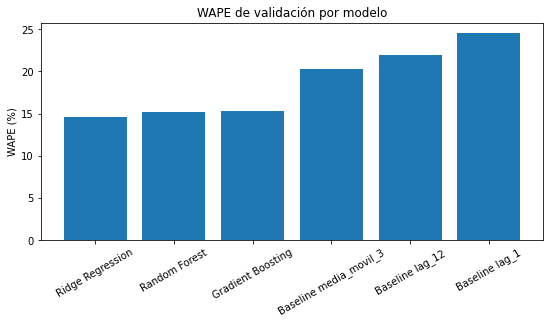

,periodo_objetivo,demanda_real,demanda_predicha
0,2025-10,"15,239.0000","14,494.1031"
1,2025-11,"15,334.0000","15,416.5726"
2,2025-12,"22,049.0000","22,211.7944"


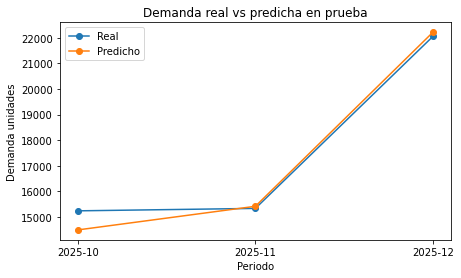

In [10]:
valid_plot = ranking_validacion.copy()
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(valid_plot["modelo"], valid_plot["WAPE"])
ax.set_title("WAPE de validación por modelo")
ax.set_ylabel("WAPE (%)")
ax.tick_params(axis="x", rotation=30)
plt.show()

modelo_operativo_validacion = modelos_entrenados_validacion[modelo_operativo]
pred_test_operativo = np.clip(modelo_operativo_validacion.predict(X_test), 0, None)

comparacion_test = test_df[["periodo_objetivo", "id_tienda", "categoria", "demanda_unidades"]].copy()
comparacion_test["prediccion"] = pred_test_operativo
comparacion_periodo = comparacion_test.groupby("periodo_objetivo", as_index=False).agg(
    demanda_real=("demanda_unidades", "sum"),
    demanda_predicha=("prediccion", "sum"),
)

display(comparacion_periodo)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(comparacion_periodo["periodo_objetivo"], comparacion_periodo["demanda_real"], marker="o", label="Real")
ax.plot(comparacion_periodo["periodo_objetivo"], comparacion_periodo["demanda_predicha"], marker="o", label="Predicho")
ax.set_title("Demanda real vs predicha en prueba")
ax.set_xlabel("Periodo")
ax.set_ylabel("Demanda unidades")
ax.legend()
plt.show()

## 11. Pronóstico operativo para enero de 2026

Para predecir enero de 2026 se reentrena el modelo operativo con toda la historia disponible hasta diciembre de 2025. Esto no genera fuga de información porque enero de 2026 es posterior al periodo observado.

La salida contiene demanda baja, central y alta para cada combinación `id_tienda × categoria`.

In [11]:
mask_historia_modelable = panel_modelo["periodo_objetivo"].between(primer_periodo_objetivo, test_fin)
historia_modelable = panel_modelo.loc[mask_historia_modelable].copy()

X_historia = features_dummy.loc[historia_modelable.index]
y_historia = historia_modelable["demanda_unidades"].astype(float)
X_forecast = features_dummy.loc[forecast_df.index]

modelo_final = crear_modelo(modelo_operativo)
modelo_final.fit(X_historia, y_historia)

pred_central = np.clip(modelo_final.predict(X_forecast), 0, None)
pred_baja = pred_central + residuo_q_inferior
pred_alta = pred_central + residuo_q_superior

if cfg_intervalo.get("truncar_limite_inferior_en_cero", True):
    pred_baja = np.clip(pred_baja, 0, None)

pred_alta = np.clip(pred_alta, 0, None)

predicciones_demanda = forecast_df[["periodo_objetivo", "id_tienda", "categoria", "tipo", "canal", "ciudad_tienda"]].copy()
predicciones_demanda["demanda_baja"] = np.rint(pred_baja).astype(int)
predicciones_demanda["demanda_predicha"] = np.rint(pred_central).astype(int)
predicciones_demanda["demanda_central"] = predicciones_demanda["demanda_predicha"]
predicciones_demanda["demanda_alta"] = np.rint(pred_alta).astype(int)

# Garantía de orden: baja <= central <= alta.
predicciones_demanda["demanda_baja"] = np.minimum(
    predicciones_demanda["demanda_baja"],
    predicciones_demanda["demanda_predicha"],
)
predicciones_demanda["demanda_alta"] = np.maximum(
    predicciones_demanda["demanda_alta"],
    predicciones_demanda["demanda_predicha"],
)

predicciones_demanda["modelo"] = modelo_operativo
predicciones_demanda["metodo_intervalo"] = "cuantiles_residuo_validacion"
predicciones_demanda["cuantil_inferior_residuo"] = q_inferior
predicciones_demanda["cuantil_superior_residuo"] = q_superior

predicciones_demanda = predicciones_demanda.sort_values(["id_tienda", "categoria"]).reset_index(drop=True)

# Columnas centrales esperadas por P4: demanda_baja, demanda_predicha y demanda_alta.
columnas_salida = [
    "periodo_objetivo",
    "id_tienda",
    "categoria",
    "tipo",
    "canal",
    "ciudad_tienda",
    "demanda_baja",
    "demanda_predicha",
    "demanda_central",
    "demanda_alta",
    "modelo",
    "metodo_intervalo",
    "cuantil_inferior_residuo",
    "cuantil_superior_residuo",
]
predicciones_demanda = predicciones_demanda[columnas_salida]

display(predicciones_demanda.head(20))
print("Filas de predicción:", len(predicciones_demanda))
print("Suma demanda baja:", int(predicciones_demanda["demanda_baja"].sum()))
print("Suma demanda central:", int(predicciones_demanda["demanda_predicha"].sum()))
print("Suma demanda alta:", int(predicciones_demanda["demanda_alta"].sum()))

,periodo_objetivo,id_tienda,categoria,tipo,canal,ciudad_tienda,demanda_baja,demanda_predicha,demanda_central,demanda_alta,modelo,metodo_intervalo,cuantil_inferior_residuo,cuantil_superior_residuo
0,2026-01,APP,Abarrotes,Virtual,App,No aplica,883,919,919,961,Ridge Regression,cuantiles_residuo_validacion,0.1000,0.9000
1,2026-01,APP,Bebidas,Virtual,App,No aplica,670,706,706,749,Ridge Regression,cuantiles_residuo_validacion,0.1000,0.9000
2,2026-01,APP,Cuidado Personal,Virtual,App,No aplica,433,470,470,512,Ridge Regression,cuantiles_residuo_validacion,0.1000,0.9000
3,2026-01,APP,Electrohogar,Virtual,App,No aplica,403,439,439,481,Ridge Regression,cuantiles_residuo_validacion,0.1000,0.9000
4,2026-01,APP,Hogar,Virtual,App,No aplica,326,362,362,404,Ridge Regression,cuantiles_residuo_validacion,0.1000,0.9000
5,2026-01,APP,Limpieza,Virtual,App,No aplica,420,457,457,499,Ridge Regression,cuantiles_residuo_validacion,0.1000,0.9000
6,2026-01,T001,Abarrotes,Fisica,Tienda,Lima,172,209,209,251,Ridge Regression,cuantiles_residuo_validacion,0.1000,0.9000
7,2026-01,T001,Bebidas,Fisica,Tienda,Lima,100,136,136,178,Ridge Regression,cuantiles_residuo_validacion,0.1000,0.9000
8,2026-01,T001,Cuidado Personal,Fisica,Tienda,Lima,50,87,87,129,Ridge Regression,cuantiles_residuo_validacion,0.1000,0.9000
9,2026-01,T001,Electrohogar,Fisica,Tienda,Lima,36,73,73,115,Ridge Regression,cuantiles_residuo_validacion,0.1000,0.9000


Filas de predicción: 90
Suma demanda baja: 11336
Suma demanda central: 14619
Suma demanda alta: 18407


## 12. Validaciones de salida

Se validan las condiciones necesarias para que `predicciones_demanda.csv` pueda ser usado por la Parte 4:

- 90 filas esperadas: 15 nodos × 6 categorías;
- sin duplicados por periodo, nodo y categoría;
- demandas no negativas;
- orden `demanda_baja <= demanda_predicha <= demanda_alta`;
- periodo operativo igual a enero de 2026.

In [12]:
esperado_filas = len(ids_tienda) * len(categorias)
duplicados = predicciones_demanda.duplicated(["periodo_objetivo", "id_tienda", "categoria"]).sum()
orden_intervalo_ok = (
    (predicciones_demanda["demanda_baja"] <= predicciones_demanda["demanda_predicha"])
    & (predicciones_demanda["demanda_predicha"] <= predicciones_demanda["demanda_alta"])
).all()
no_negativas_ok = (
    predicciones_demanda[["demanda_baja", "demanda_predicha", "demanda_alta"]] >= 0
).all().all()
periodo_ok = predicciones_demanda["periodo_objetivo"].eq(cfg_demanda["periodo_pronostico_operativo"]).all()

validaciones_salida = pd.DataFrame([
    {"criterio": "filas_esperadas", "valor": len(predicciones_demanda), "esperado": esperado_filas, "ok": len(predicciones_demanda) == esperado_filas},
    {"criterio": "duplicados_periodo_nodo_categoria", "valor": int(duplicados), "esperado": 0, "ok": duplicados == 0},
    {"criterio": "demandas_no_negativas", "valor": bool(no_negativas_ok), "esperado": True, "ok": bool(no_negativas_ok)},
    {"criterio": "orden_intervalo", "valor": bool(orden_intervalo_ok), "esperado": True, "ok": bool(orden_intervalo_ok)},
    {"criterio": "periodo_operativo", "valor": predicciones_demanda["periodo_objetivo"].unique().tolist(), "esperado": cfg_demanda["periodo_pronostico_operativo"], "ok": bool(periodo_ok)},
])

display(validaciones_salida)

if not validaciones_salida["ok"].all():
    raise ValueError("Las predicciones de demanda no cumplen las validaciones de salida.")

,criterio,valor,esperado,ok
0,filas_esperadas,90,90,True
1,duplicados_periodo_nodo_categoria,0,0,True
2,demandas_no_negativas,True,True,True
3,orden_intervalo,True,True,True
4,periodo_operativo,[2026-01],2026-01,True


## 13. Exportación

Se exporta `resultados/predicciones_demanda.csv`. Este archivo será insumo de la Parte 4 prescriptiva.

In [13]:
predicciones_demanda.to_csv(OUT_PREDICCIONES, index=False, encoding="utf-8")
print(f"Archivo exportado: {OUT_PREDICCIONES.relative_to(ROOT)}")
print(f"Filas: {len(predicciones_demanda):,}")
print(f"Columnas: {predicciones_demanda.shape[1]}")

Archivo exportado: resultados\predicciones_demanda.csv
Filas: 90
Columnas: 14


## 14. Interpretación de negocio

El modelo de demanda permite convertir el historial transaccional en un pronóstico operativo por nodo y categoría para enero de 2026. La separación temporal evita entrenar con información futura y las variables de rezago garantizan que cada predicción use únicamente demanda observada antes del periodo objetivo.

La demanda baja, central y alta ofrece un rango operativo para la Parte 4. La demanda central se usará como escenario base de reposición; la demanda baja y alta permitirán evaluar sensibilidad ante menor o mayor presión de demanda.

,categoria,demanda_baja,demanda_predicha,demanda_alta
0,Abarrotes,3742,4290,4920
1,Bebidas,2803,3350,3981
2,Cuidado Personal,1435,1986,2617
5,Limpieza,1383,1931,2564
3,Electrohogar,1130,1676,2307
4,Hogar,843,1386,2018


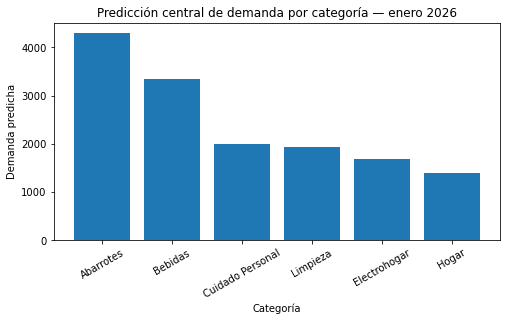

Conclusión:
La salida predicciones_demanda.csv queda lista para la Parte 4. Contiene predicción mensual por nodo y categoría, intervalos empíricos de demanda y columnas compatibles con el modelo prescriptivo.


In [14]:
resumen_forecast_categoria = (
    predicciones_demanda.groupby("categoria", as_index=False)
    .agg(
        demanda_baja=("demanda_baja", "sum"),
        demanda_predicha=("demanda_predicha", "sum"),
        demanda_alta=("demanda_alta", "sum"),
    )
    .sort_values("demanda_predicha", ascending=False)
)

display(resumen_forecast_categoria)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(resumen_forecast_categoria["categoria"], resumen_forecast_categoria["demanda_predicha"])
ax.set_title("Predicción central de demanda por categoría — enero 2026")
ax.set_xlabel("Categoría")
ax.set_ylabel("Demanda predicha")
ax.tick_params(axis="x", rotation=30)
plt.show()

print("Conclusión:")
print(
    "La salida predicciones_demanda.csv queda lista para la Parte 4. "
    "Contiene predicción mensual por nodo y categoría, intervalos empíricos de demanda "
    "y columnas compatibles con el modelo prescriptivo."
)